<a href="https://colab.research.google.com/github/pmkmohan/AI-And-GEN-AI/blob/main/Image_Classification_with_Maxpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Sep 17 02:25:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
import random
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 13556028763182508031
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 14426112000
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 10720861490624510310
 physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
 xla_global_id: 416903419]

In [3]:
img = image.load_img('/content/drive/MyDrive/Training/Happy/20150328_071155.jpg')

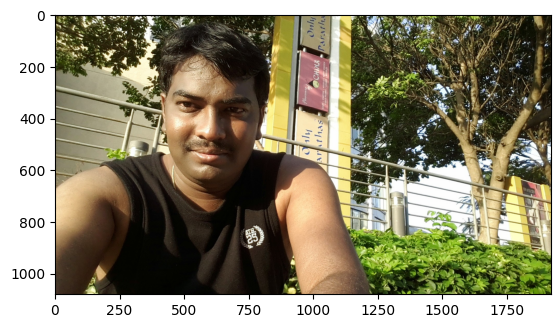

In [4]:
plt.imshow(img)

In [5]:
i1 = cv2.imread('/content/drive/MyDrive/Training/Happy/20150328_071155.jpg')
i1

array([[[ 25,  44,  49],
        [ 24,  43,  48],
        [ 18,  38,  43],
        ...,
        [  6,  25,  30],
        [ 16,  35,  38],
        [ 19,  38,  41]],

       [[ 30,  49,  54],
        [ 29,  49,  54],
        [ 24,  44,  49],
        ...,
        [  3,  22,  27],
        [ 12,  31,  34],
        [ 15,  34,  37]],

       [[ 18,  38,  43],
        [ 19,  41,  46],
        [ 15,  37,  42],
        ...,
        [  4,  23,  28],
        [  8,  27,  30],
        [  9,  28,  31]],

       ...,

       [[ 37,  50,  64],
        [ 39,  52,  66],
        [ 40,  53,  67],
        ...,
        [ 87, 168, 143],
        [ 43, 115,  92],
        [  0,  37,  14]],

       [[ 35,  48,  62],
        [ 37,  50,  64],
        [ 39,  52,  66],
        ...,
        [ 73, 145, 122],
        [ 24,  88,  66],
        [ 13,  75,  53]],

       [[ 37,  50,  64],
        [ 37,  50,  64],
        [ 37,  50,  64],
        ...,
        [ 64, 132, 109],
        [ 40, 102,  80],
        [  0,  31,  10]]

In [6]:
i1.shape

(1080, 1920, 3)

In [7]:
train = ImageDataGenerator(rescale=1/200)
validation = ImageDataGenerator(rescale=1/200)

In [8]:
train_dataset = train.flow_from_directory('/content/drive/MyDrive/Training',
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode='binary')
validation_dataset = train.flow_from_directory('/content/drive/MyDrive/Validation',
                                               target_size=(200,200),
                                          batch_size=32,
                                          class_mode='binary')

Found 14 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
train_dataset.class_indices

{'Happy': 0, 'NotHappy': 1}

In [11]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [12]:
model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3),activation='relu',
                                                           input_shape = (200,200,3)),
                                   tf.keras.layers.MaxPool2D(2,2), #3filters we can apply here
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                     tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                     tf.keras.layers.Flatten(),
                                     ##
                                     tf.keras.layers.Dense(512,activation='relu'),
                                     ##
                                     tf.keras.layers.Dense(1,activation='sigmoid')

                                    ]
                                   )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [14]:
model_fit = model.fit(train_dataset,epochs=20)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5714 - loss: 0.6903
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step - accuracy: 0.5714 - loss: 8.2988
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step - accuracy: 0.4286 - loss: 8.0295
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step - accuracy: 0.6429 - loss: 0.6692
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step - accuracy: 0.5714 - loss: 0.6960
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 0.4286 - loss: 0.8993
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.5714 - loss: 0.5879
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step - accuracy: 0.8571 - loss: 0.5199
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step - accuracy: 0.7857 - loss: 0.4633
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - accuracy: 0.8571 - loss: 0.4015
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step - accuracy: 0.7857 - loss: 0.3532
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step - accuracy: 0.5000 - loss:

In [15]:
dir_path = ('/content/drive/MyDrive/Testing')
for i in os.listdir(dir_path):
  print(i)

DSC04180.JPG
20150328_070844.jpg
20150327_100440.jpg
20150405_155118.jpg
20150411_112001.jpg
20150503_125429.jpg
20150509_144451.jpg
20150509_113925.jpg


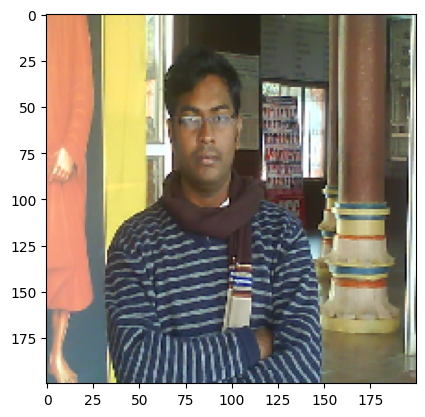

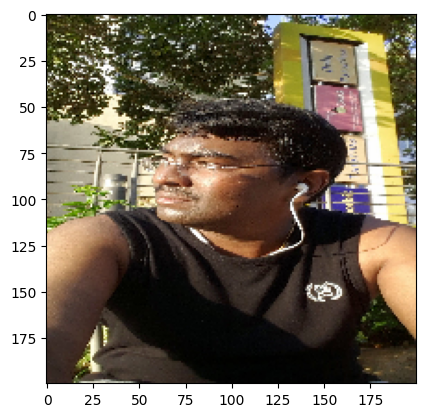

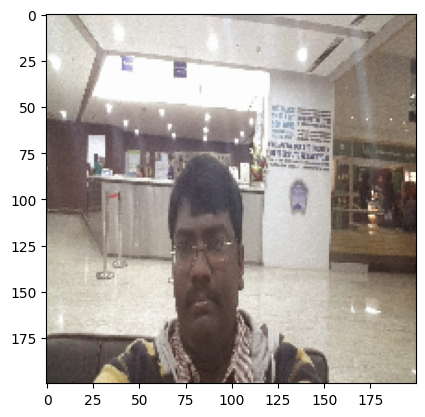

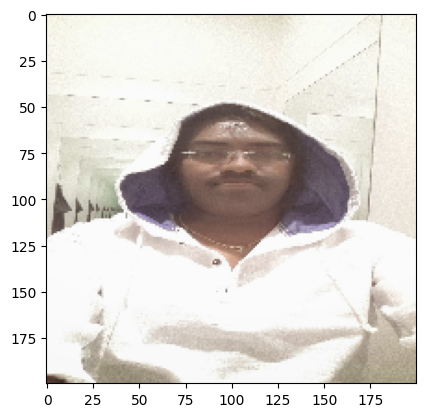

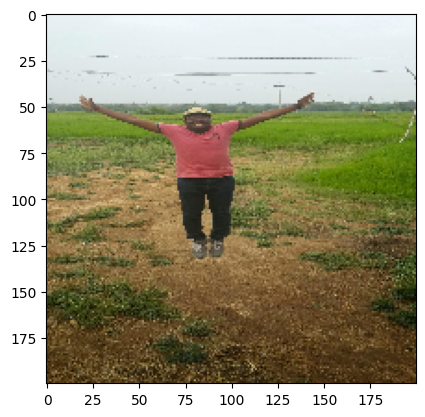

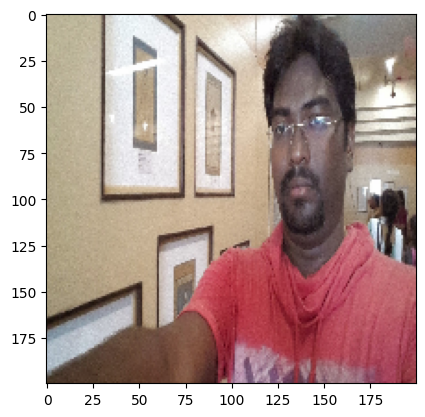

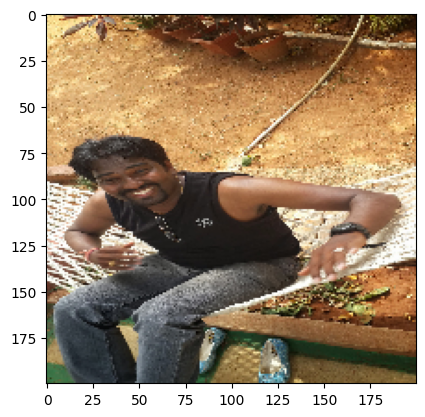

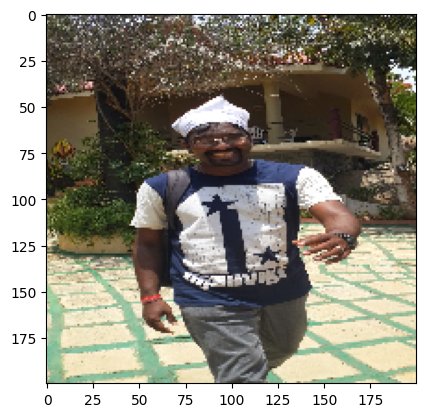

In [16]:
dir_path = ('/content/drive/MyDrive/Testing')
for i in os.listdir(dir_path):
  img = image.load_img(dir_path+ '//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

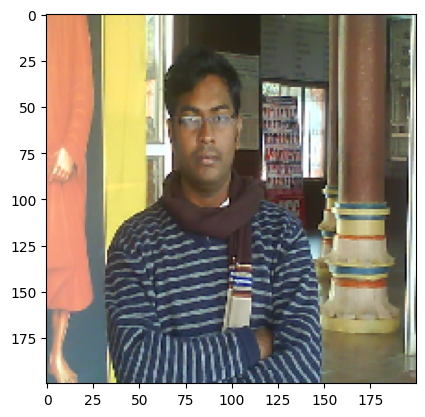

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
I am not Happy


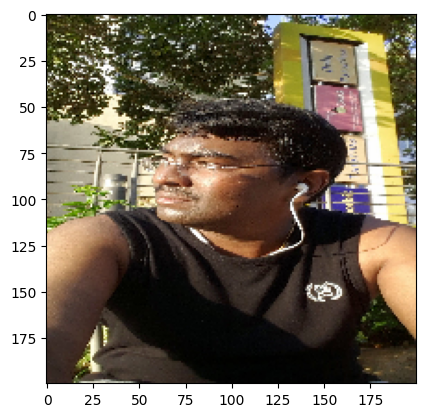

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
I am not Happy


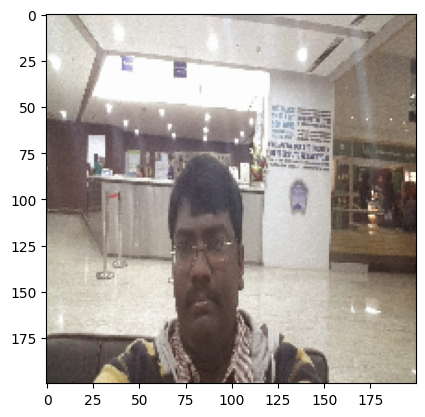

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
I am not Happy


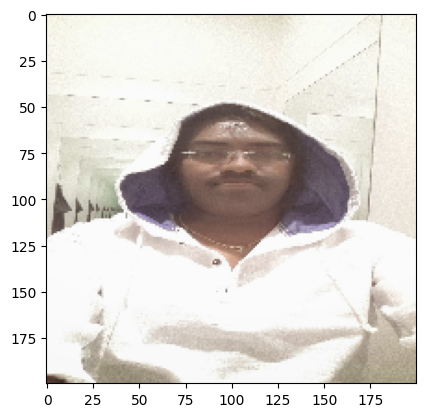

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
I am not Happy


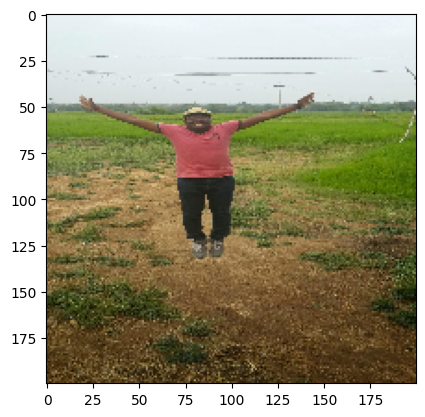

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
I am not Happy


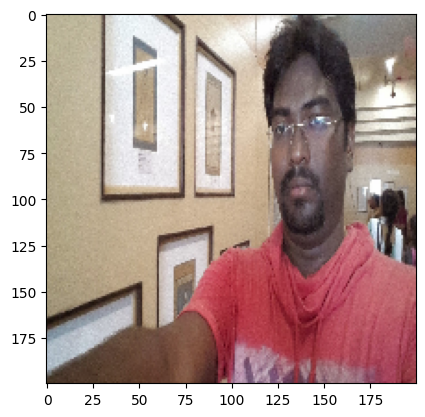

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
I am not Happy


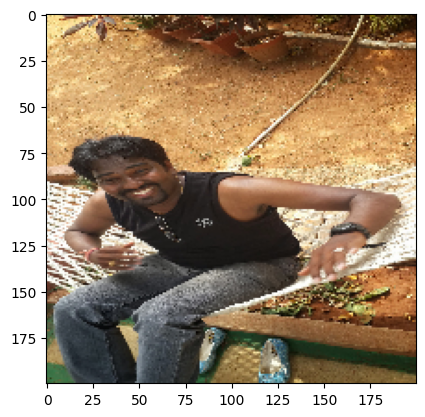

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
I am Happy


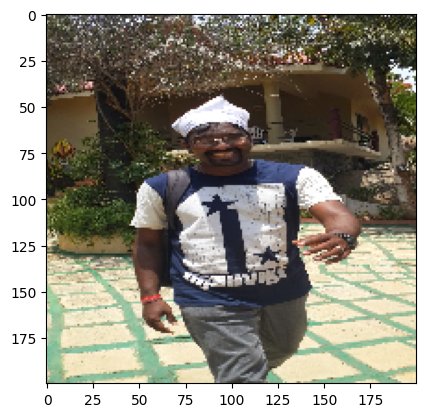

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
I am Happy


In [17]:
dir_path = ('/content/drive/MyDrive/Testing')
for i in os.listdir(dir_path):
  img = image.load_img(dir_path+ '//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

  x= image.img_to_array(img)
  x = np.expand_dims(x,axis = 0)
  images = np.vstack([x])

  val = model.predict(images)
  if val == 0:
    print('I am Happy')
  else:
    print('I am not Happy')


In [18]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
  #resize the image to (200,200) as expected by the model
  img = image.resize((200,200))
  # convert the image to a numpy array
  x = np.array(img)
  # Expanding dimensions to create a batch of 1 image
  x = np.expand_dims(x,axis=0)
  # Normalize the image(if the model was trained with normalized inputs)
  # The model was trained with rescale =1/200, so we should apply the same scaling here.
  x=x/200.0
  #Make prediction
  val = model.predict(x)
  if val == 0.5:
    return 'I am Happy'
  else:
    return 'I am not Happy'

In [19]:
from gradio.components import label
iface = gr.Interface(fn =predict_mood,
                     inputs=gr.Image(type="pil",label ='Upload an Image'),
                     outputs=gr.Text(label='Prediction Mood'),
                     title = "Mood Classification (Happy/Not Happy)",
                     description="Upload an image to classify if the person is hapy or not happy"
                     )
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cdccb2808297bfb339.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
